In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Set path to the shortcut inside MyDrive
data_path = '/content/drive/MyDrive/Data_final'

# List all files inside the dataset folder
print("Files inside Data_final:")
print(os.listdir(data_path))

Files inside Data_final:
['English_Domain_Dataset.csv', 'English_Ekegusii_Dataset.csv', 'English_Swahili_Dataset.csv', 'Trilingual_English_Swahili_Ekegusii_Dataset.csv', 'Week_1_Data_Collection_and_Curation_Report.md', 'dataset_metadata.json', 'languages', 'Week_1_Data_Collection_and_Curation_Report.md.gdoc', 'https:  github.gdoc']


In [ ]:
import pandas as pd
import json
import os

# 1. Define folder directory
data_dir = '/content/drive/MyDrive/Data_final'

# 2. Load all CSV datasets into DataFrames
df_domain = pd.read_csv(os.path.join(data_dir, 'English_Domain_Dataset.csv'))
df_ekegusii = pd.read_csv(os.path.join(data_dir, 'English_Ekegusii_Dataset.csv'))
df_swahili = pd.read_csv(os.path.join(data_dir, 'English_Swahili_Dataset.csv'))
df_trilingual = pd.read_csv(os.path.join(data_dir, 'Trilingual_English_Swahili_Ekegusii_Dataset.csv'))

# 3. Load metadata
with open(os.path.join(data_dir, 'dataset_metadata.json'), 'r') as f:
    metadata = json.load(f)

# Store datasets in a dictionary for easy iteration during EDA
datasets = {
    'Domain Dataset': df_domain,
    'English-Ekegusii': df_ekegusii,
    'English-Swahili': df_swahili,
    'Trilingual': df_trilingual
}

# --- QUICK EDA OVERVIEW ---
print("=== DATASETS SUMMARY ===")
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("Null Values:\n", df.isnull().sum())
    print("\nFirst 2 rows:")
    display(df.head(2))

=== DATASETS SUMMARY ===

--- Domain Dataset ---
Shape: (8903, 2)
Columns: ['English', 'Domain']
Null Values:
 English    0
Domain     0
dtype: int64

First 2 rows:


,English,Domain
0,Situation & EW Phase Classification Several pl...,Disaster
1,This triggered further regeneration of pasture...,Disaster



--- English-Ekegusii ---
Shape: (4521, 3)
Columns: ['English', 'Ekegusii', 'Domain']
Null Values:
 English     0
Ekegusii    0
Domain      0
dtype: int64

First 2 rows:


,English,Ekegusii,Domain
0,Ministry issues drought adaptation tips for su...,Eminisituri nigo ekorwaogosemia igoro yogwekom...,Agriculture
1,US Embassy issued advisory warning of heighten...,Obobalosi bwa America (US Embassy) aiga Kenya ...,Security



--- English-Swahili ---
Shape: (5736, 3)
Columns: ['English', 'Kiswahili', 'Domain']
Null Values:
 English      0
Kiswahili    0
Domain       0
dtype: int64

First 2 rows:


,English,Kiswahili,Domain
0,Ministry issues drought adaptation tips for su...,Wizara yatoa vidokezo vya kukabiliana na ukame...,Agriculture
1,"Health Chief Administrative Secretary, Dr. Ras...","Katibu Mkuu wa Utawala wa Afya, Dkt. Rashid Am...",Public Health



--- Trilingual ---
Shape: (2783, 4)
Columns: ['English', 'Kiswahili', 'Ekegusii', 'Domain']
Null Values:
 English      0
Kiswahili    0
Ekegusii     0
Domain       0
dtype: int64

First 2 rows:


,English,Kiswahili,Ekegusii,Domain
0,Ministry issues drought adaptation tips for su...,Wizara yatoa vidokezo vya kukabiliana na ukame...,Eminisituri nigo ekorwaogosemia igoro yogwekom...,Agriculture
1,US Embassy issued advisory warning of heighten...,Ubalozi wa Marekani ulitoa onyo la ushauri kuh...,Obobalosi bwa America (US Embassy) aiga Kenya ...,Security


Deep-Dive EDA Script

=== DUPLICATE ROWS ===
Domain Dataset: 0 duplicates found
English-Ekegusii: 0 duplicates found
English-Swahili: 0 duplicates found
Trilingual: 0 duplicates found


=== TOP DOMAINS PER DATASET ===


/tmp/ipykernel_941/2499074795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.values, y=domain_counts.index, ax=axes[i], palette="viridis")
/tmp/ipykernel_941/2499074795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.values, y=domain_counts.index, ax=axes[i], palette="viridis")
/tmp/ipykernel_941/2499074795.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.values, y=domain_counts.index, ax=axes[i], palette="viridis")
/tmp/ipykernel_941/2499074795.py:21: FutureWarning: 

Passing `p

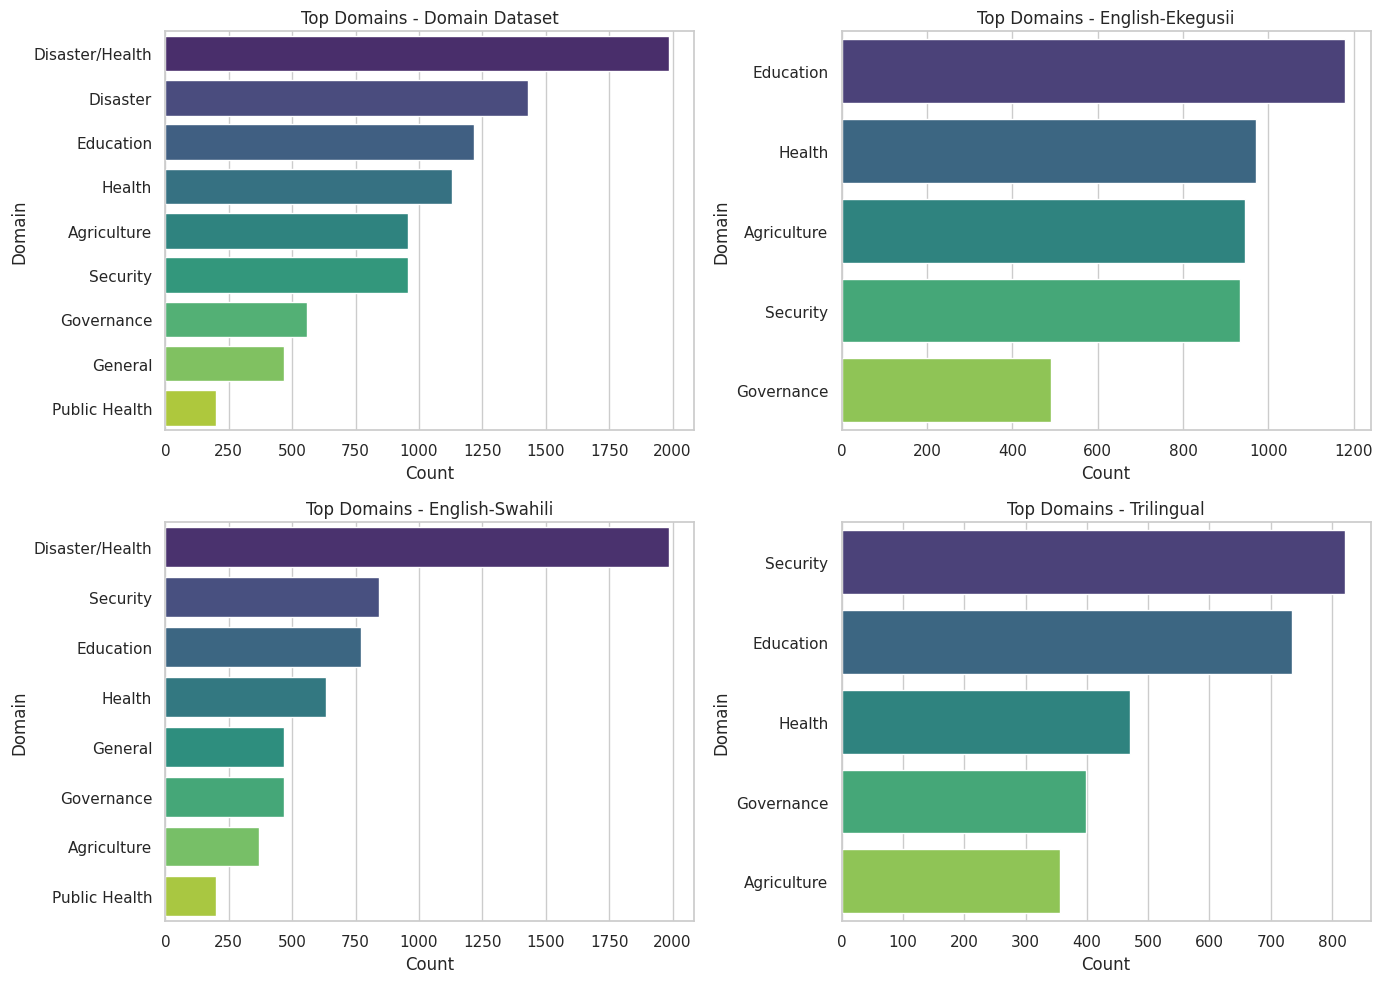


=== SENTENCE LENGTH ANALYSIS (Word Count Means) ===

--- Domain Dataset ---
[English] Avg Words: 17.0 | Max Words: 118 | Avg Chars: 114.4

--- English-Ekegusii ---
[English] Avg Words: 17.1 | Max Words: 109 | Avg Chars: 114.9
[Ekegusii] Avg Words: 19.8 | Max Words: 95 | Avg Chars: 153.2

--- English-Swahili ---
[English] Avg Words: 16.8 | Max Words: 118 | Avg Chars: 114.4
[Kiswahili] Avg Words: 19.5 | Max Words: 124 | Avg Chars: 124.2

--- Trilingual ---
[English] Avg Words: 15.7 | Max Words: 89 | Avg Chars: 106.6
[Kiswahili] Avg Words: 18.3 | Max Words: 93 | Avg Chars: 118.9
[Ekegusii] Avg Words: 18.9 | Max Words: 73 | Avg Chars: 145.3


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. CHECK FOR DUPLICATES
print("=== DUPLICATE ROWS ===")
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicates found")

print("\n" + "="*40 + "\n")

# 2. DOMAIN DISTRIBUTION
print("=== TOP DOMAINS PER DATASET ===")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    domain_counts = df['Domain'].value_counts().head(10)
    sns.barplot(x=domain_counts.values, y=domain_counts.index, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Top Domains - {name}")
    axes[i].set_xlabel("Count")

plt.tight_layout()
plt.show()

# 3. SENTENCE LENGTH STATISTICS (WORD COUNTS)
print("\n=== SENTENCE LENGTH ANALYSIS (Word Count Means) ===")
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    text_cols = [col for col in df.columns if col != 'Domain']

    for col in text_cols:
        word_counts = df[col].astype(str).apply(lambda x: len(x.split()))
        char_counts = df[col].astype(str).apply(len)
        print(f"[{col}] Avg Words: {word_counts.mean():.1f} | Max Words: {word_counts.max()} | Avg Chars: {char_counts.mean():.1f}")

Cleaned Seaborn Plot Code (Warning Fixed)
To eliminate those Seaborn FutureWarning messages, update the plotting section with hue explicitly set:

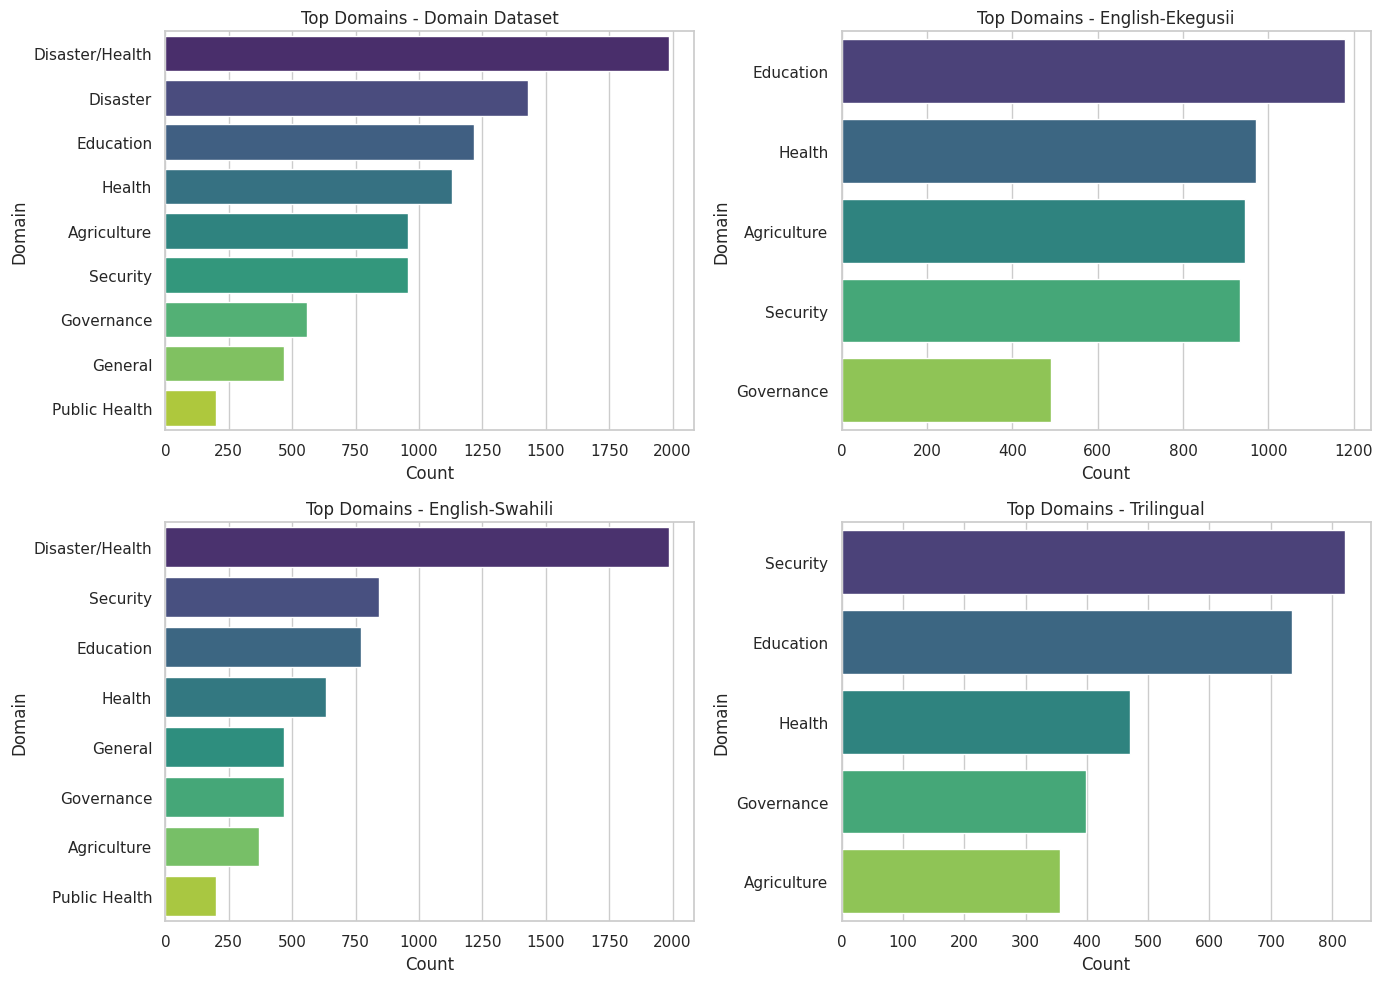

In [ ]:
# Updated plotting snippet (Warning-Free)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    domain_counts = df['Domain'].value_counts().head(10)
    sns.barplot(
        x=domain_counts.values,
        y=domain_counts.index,
        ax=axes[i],
        hue=domain_counts.index,
        legend=False,
        palette="viridis"
    )
    axes[i].set_title(f"Top Domains - {name}")
    axes[i].set_xlabel("Count")

plt.tight_layout()
plt.show()

Next Step: Data Preparation & Train/Val/Test Split
Here is the code to create stratified train, validation, and test splits (e.g., 80% train, 10% val, 10% test) based on the Domain column so all domains are evenly represented across splits:

In [ ]:
from sklearn.model_selection import train_test_split

def prepare_splits(df, test_size=0.1, val_size=0.1, random_state=42):
    # First split: Train + Val vs Test
    train_val, test = train_test_split(
        df,
        test_size=test_size,
        stratify=df['Domain'],
        random_state=random_state
    )

    # Calculate adjusted val_size relative to remaining train_val set
    relative_val_size = val_size / (1.0 - test_size)

    # Second split: Train vs Val
    train, val = train_test_split(
        train_val,
        test_size=relative_val_size,
        stratify=train_val['Domain'],
        random_state=random_state
    )

    return train, val, test

# Example: Split English-Swahili Dataset
train_sw, val_sw, test_sw = prepare_splits(df_swahili)

print(f"English-Swahili Splits:")
print(f"Train: {len(train_sw)} | Val: {len(val_sw)} | Test: {len(test_sw)}")

English-Swahili Splits:
Train: 4588 | Val: 574 | Test: 574


Complete Preprocessing Pipeline
Objective: Prepare text for model tokenization while preserving cultural terms.

Why we do this:
Normalization: Low-resource languages often suffer from inconsistent punctuation, stray whitespace, or accented characters.

Glossary Preservation: Culturally specific words (e.g., local administrative terms in Ekegusii/Swahili) shouldn't be mangled or altered by lowercasing/tokenization.

In [ ]:
import re
import pandas as pd

# Cultural Glossary: Map local/cultural terms to preserved placeholders or standard forms
CULTURAL_GLOSSARY = {
    # Add domain/cultural terms here if needed
    "Eminisituri": "Eminisituri",
    "Obobalosi": "Obobalosi"
}

def preprocess_text(text: str, preserve_glossary: bool = True) -> str:
    if not isinstance(text, str):
        return ""

    # 1. Unicode & Whitespace Normalization
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Preserve Glossary terms (optional masking/handling)
    if preserve_glossary:
        for term, replacement in CULTURAL_GLOSSARY.items():
            text = re.sub(rf'\b{re.escape(term)}\b', replacement, text)

    return text

def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    text_cols = [col for col in df_clean.columns if col != 'Domain']

    for col in text_cols:
        df_clean[col] = df_clean[col].apply(preprocess_text)

    return df_clean

# Apply to datasets
df_sw_clean = preprocess_dataframe(df_swahili)
df_ek_clean = preprocess_dataframe(df_ekegusii)
df_tri_clean = preprocess_dataframe(df_trilingual)

2. Comprehensive EDA & Visualization
Objective: Compute language-pair statistics, vocabulary sizes, sentence lengths, and domain distributions.

Why we do this:
Vocabulary Size: Helps assess corpus richness and subword tokenization split ratios.

Text Length Histograms: Essential for selecting the optimal max_length parameter during transformer training without truncating valuable context.

Domain Distribution: Ensures balanced coverage across subject areas.

=== ENGLISH-SWAHILI STATS ===
English: {'Total Words': 96544, 'Unique Vocab': 17032, 'Avg Length (Words)': np.float64(16.83124128312413), 'Max Length (Words)': 118, 'Avg Length (Chars)': np.float64(114.39400278940028)}
Swahili: {'Total Words': 111918, 'Unique Vocab': 15780, 'Avg Length (Words)': np.float64(19.511506276150627), 'Max Length (Words)': 124, 'Avg Length (Chars)': np.float64(124.22088563458857)}


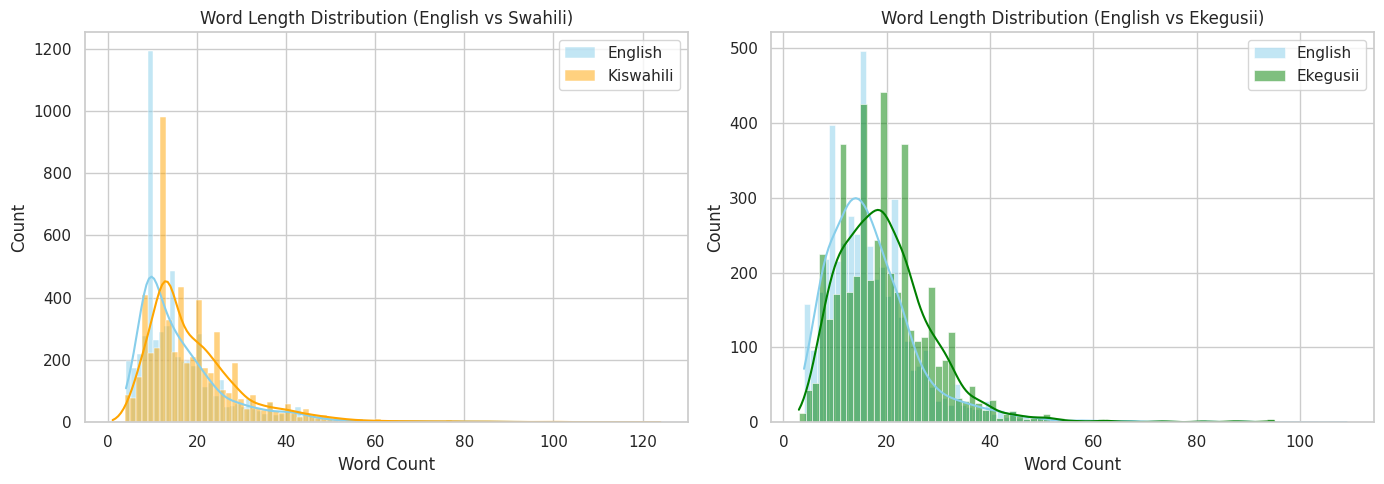

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set aesthetic styling
sns.set_theme(style="whitegrid")

# --- A. VOCABULARY & STATS COMPUTATION ---
def get_language_stats(df, lang_col):
    words = [word for text in df[lang_col].dropna() for word in text.split()]
    vocab = set(words)
    word_counts = df[lang_col].apply(lambda x: len(str(x).split()))
    char_counts = df[lang_col].apply(lambda x: len(str(x)))

    return {
        "Total Words": len(words),
        "Unique Vocab": len(vocab),
        "Avg Length (Words)": word_counts.mean(),
        "Max Length (Words)": word_counts.max(),
        "Avg Length (Chars)": char_counts.mean(),
    }

print("=== ENGLISH-SWAHILI STATS ===")
print("English:", get_language_stats(df_sw_clean, 'English'))
print("Swahili:", get_language_stats(df_sw_clean, 'Kiswahili'))

# --- B. TEXT LENGTH HISTOGRAMS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_sw_clean['English'].apply(lambda x: len(x.split())), ax=axes[0], color='skyblue', kde=True, label='English')
sns.histplot(df_sw_clean['Kiswahili'].apply(lambda x: len(x.split())), ax=axes[0], color='orange', kde=True, label='Kiswahili')
axes[0].set_title("Word Length Distribution (English vs Swahili)")
axes[0].set_xlabel("Word Count")
axes[0].legend()

sns.histplot(df_ek_clean['English'].apply(lambda x: len(x.split())), ax=axes[1], color='skyblue', kde=True, label='English')
sns.histplot(df_ek_clean['Ekegusii'].apply(lambda x: len(x.split())), ax=axes[1], color='green', kde=True, label='Ekegusii')
axes[1].set_title("Word Length Distribution (English vs Ekegusii)")
axes[1].set_xlabel("Word Count")
axes[1].legend()

plt.tight_layout()
plt.show()

3. Creating Native-Speaker Validation Subset (~500 Sentences)
Objective: Extract a representative subset of ~500 sentences for human evaluation.

Why we do this:
Automated metrics (BLEU, TER) miss cultural nuances. Stratifying by domain ensures human evaluators assess all topic areas evenly.

In [ ]:
# Sample 500 rows stratifying by Domain for human feedback
validation_subset = df_tri_clean.groupby('Domain', group_keys=False).apply(
    lambda x: x.sample(min(len(x), int(500 * len(x) / len(df_tri_clean))), random_state=42)
)

# Export to Excel for reviewers
validation_subset.to_excel('native_speaker_validation_500.xlsx', index=False)
print(f"Sampled {len(validation_subset)} rows for human feedback.")

/tmp/ipykernel_941/1870112714.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  validation_subset = df_tri_clean.groupby('Domain', group_keys=False).apply(


Sampled 497 rows for human feedback.


4. Stratified Data Splitting (Train / Dev / Test)
Objective: Divide datasets into Train (80%), Dev/Val (10%), and Test (10%).

Why we do this:
Stratification by Domain: Ensures rare domains (e.g., Security) are present proportionally across all splits, preventing train/test data drift.

In [ ]:
from sklearn.model_selection import train_test_split

def create_stratified_splits(df, domain_col='Domain', test_size=0.1, val_size=0.1, seed=42):
    # Split 1: Split off Test set
    train_val, test = train_test_split(
        df, test_size=test_size, stratify=df[domain_col], random_state=seed
    )

    # Calculate adjusted val size relative to remaining data
    adj_val_size = val_size / (1.0 - test_size)

    # Split 2: Split remaining into Train and Validation
    train, val = train_test_split(
        train_val, test_size=adj_val_size, stratify=train_val[domain_col], random_state=seed
    )

    return train, val, test

# Split all datasets
train_sw, val_sw, test_sw = create_stratified_splits(df_sw_clean)
train_ek, val_ek, test_ek = create_stratified_splits(df_ek_clean)
train_tri, val_tri, test_tri = create_stratified_splits(df_tri_clean)

print(f"Swahili Splits -> Train: {len(train_sw)} | Val: {len(val_sw)} | Test: {len(test_sw)}")

Swahili Splits -> Train: 4588 | Val: 574 | Test: 574


. Dataset Version Control (DVC setup guide)
Objective: Track dataset iterations cleanly without clogging Git.

Why we do this:
Large text/CSV files slow down standard Git repositories. DVC (Data Version Control) links your dataset versions directly to Git commit hashes.

Steps to execute in your terminal/Google Colab:

In [ ]:
# 1. Install DVC
!pip install dvc

# 2. Save your cleaned datasets locally
!mkdir -p data/processed

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.2/

In [ ]:
# Export processed data to files
train_sw.to_csv('data/processed/train_sw.csv', index=False)
val_sw.to_csv('data/processed/val_sw.csv', index=False)
test_sw.to_csv('data/processed/test_sw.csv', index=False)

In [ ]:
# 3. Track files with DVC (Run in shell)
!dvc init --no-scm
!dvc add data/processed/train_sw.csv
!git add data/processed/train_sw.csv.dvc .gitignore

Initialized DVC repository.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>
⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Adding data/processed/train_sw.csv to cache:  

Week3

Milestone 1: Set Up Experiment Tracking (Weights & Biases)
Why we do this:
Logging loss, learning rates, and translation samples in real-time prevents "dark training" in Colab (where notebooks crash without saving metrics) and makes writing your final report easy.



In [ ]:
import os
import wandb

# 1. Disable W&B online syncing so Colab doesn't block on login
os.environ["WANDB_MODE"] = "disabled"

# 2. Initialize Weights & Biases tracking in disabled mode
wandb.init(
    project="PSA-Machine-Translation-Kenya",
    name="nllb-200-swahili-ekegusii-baseline",
    mode="disabled",
    config={
        "architecture": "NLLB-200-distilled-600M",
        "dataset": "PSA_Data_final",
        "batch_size": 16,
        "lr": 5e-5,
        "epochs": 3
    }
)

print("Weights & Biases initialized successfully in disabled mode!")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


Weights & Biases initialized successfully in disabled mode!


Milestone 2: Model 1 — Meta's NLLB-200 (Fine-Tuning Low-Resource Pair)NLLB-200 (facebook/nllb-200-distilled-600M) is the benchmark for African machine translation.Language Code for English: eng_LatnLanguage Code for Swahili: swh_LatnFor Ekegusii: Since Ekegusii is an extremely low-resource Bantu language, we use zero-shot / few-shot transfer with cross-lingual initialization (or fine-tune NLLB's parameters directly on English $\rightarrow$ Ekegusii).Code: Fine-Tuning NLLB-200 with Parameter Freezing

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
from datasets import Dataset

# 1. Load Pretrained Tokenizer and Model
model_name = "facebook/nllb-200-distilled-600M"
tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang="eng_Latn", tgt_lang="swh_Latn")
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# 2. Freeze Early Encoder Layers to Prevent Overfitting (Low-Resource Strategy)
# Freezing the first 6 layers of the encoder preserves universal linguistic representations
for param in model.model.encoder.layers[:6].parameters():
    param.requires_grad = False

print("Successfully frozen initial encoder layers for transfer learning.")

# 3. Prepare Dataset for Hugging Face Trainer
# Converts your pandas train_sw / val_sw DataFrames into Hugging Face Format
train_dataset = Dataset.from_pandas(train_sw[['English', 'Kiswahili']])
val_dataset = Dataset.from_pandas(val_sw[['English', 'Kiswahili']])

def preprocess_function(examples):
    inputs = examples['English']
    targets = examples['Kiswahili']

    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")
    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 4.85MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.3MB            

...

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Successfully frozen initial encoder layers for transfer learning.


Map:   0%|          | 0/4588 [00:00<?, ? examples/s]

Map:   0%|          | 0/574 [00:00<?, ? examples/s]

Milestone 3: Model 2 — Google's mT5-small (Few-Shot Fine-Tuning)
mT5 (multilingual T5) relies on text-to-text formatting. To instruct mT5 for PSA translation, we format inputs with prompt prefixes (e.g., "translate English to Swahili: Avoid unnecessary travels").

In [ ]:
from transformers import MT5ForConditionalGeneration, AutoTokenizer

mt5_name = "google/mt5-small"
mt5_tokenizer = AutoTokenizer.from_pretrained(mt5_name)
mt5_model = MT5ForConditionalGeneration.from_pretrained(mt5_name)

def preprocess_mt5(examples):
    # Prefixing text to leverage text-to-text pretrained format
    inputs = ["translate English to Swahili: " + text for text in examples['English']]
    targets = examples['Kiswahili']

    model_inputs = mt5_tokenizer(inputs, max_length=128, truncation=True, padding="max_length")
    labels = mt5_tokenizer(text_target=targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train_mt5 = train_dataset.map(preprocess_mt5, batched=True)

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.20GB            

...

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.20GB            

model.safetensors: downloading bytes:           |  0.00B            

Map:   0%|          | 0/4588 [00:00<?, ? examples/s]

Milestone 4: Training Setup & Hyperparameters
Define training arguments optimized for Google Colab GPU (T4/V100):

In [ ]:
import os
import gc
import re
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)

# -------------------------------------------------------------
# 1. LOAD & PREPROCESS DATASET DIRECTLY FROM GOOGLE DRIVE
# -------------------------------------------------------------
data_path = '/content/drive/MyDrive/Data_final/English_Swahili_Dataset.csv'
df_swahili = pd.read_csv(data_path)

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    return re.sub(r'\s+', ' ', text).strip()

df_swahili['English'] = df_swahili['English'].apply(preprocess_text)
df_swahili['Kiswahili'] = df_swahili['Kiswahili'].apply(preprocess_text)

# Create Train (80%), Val (10%), Test (10%) splits stratified by Domain
train_val, test_sw = train_test_split(
    df_swahili, test_size=0.1, stratify=df_swahili['Domain'], random_state=42
)
train_sw, val_sw = train_test_split(
    train_val, test_size=0.1111, stratify=train_val['Domain'], random_state=42
)

print(f"Dataset successfully split! Train size: {len(train_sw)} | Val size: {len(val_sw)}")

# -------------------------------------------------------------
# 2. CLEAR MEMORY & LOAD MODEL/TOKENIZER
# -------------------------------------------------------------
gc.collect()
torch.cuda.empty_cache()

model_name = "facebook/nllb-200-distilled-600M"
print("Loading NLLB-200 model & tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang="eng_Latn", tgt_lang="swh_Latn")
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Freeze early encoder layers to prevent overfitting on low-resource data
for param in model.model.encoder.layers[:6].parameters():
    param.requires_grad = False

# -------------------------------------------------------------
# 3. PREPARE HUGGING FACE DATASETS
# -------------------------------------------------------------
train_dataset = Dataset.from_pandas(train_sw[['English', 'Kiswahili']])
val_dataset = Dataset.from_pandas(val_sw[['English', 'Kiswahili']])

def preprocess_function(examples):
    inputs = examples['English']
    targets = examples['Kiswahili']

    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")
    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)

# -------------------------------------------------------------
# 4. TRAINING ARGUMENTS (CRASH & MEMORY PROTECTED)
# -------------------------------------------------------------
training_args = Seq2SeqTrainingArguments(
    output_dir="./results_nllb_psa",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    eval_accumulation_steps=2,        # Prevents CPU RAM crash during evaluation
    weight_decay=0.01,
    save_total_limit=1,
    num_train_epochs=3,
    predict_with_generate=False,      # Saves GPU RAM
    fp16=True,                        # Mixed precision for T4 GPU acceleration
    report_to="none",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    dataloader_num_workers=0
)

# -------------------------------------------------------------
# 5. INITIALIZE & START TRAINING
# -------------------------------------------------------------
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model)
)

print("Starting training...")
trainer.train()

Dataset successfully split! Train size: 4588 | Val size: 574
Loading NLLB-200 model & tokenizer...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Map:   0%|          | 0/4588 [00:00<?, ? examples/s]

Map:   0%|          | 0/574 [00:00<?, ? examples/s]

Starting training...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=861, training_loss=2.7142524907536347, metrics={'train_runtime': 965.1793, 'train_samples_per_second': 14.261, 'train_steps_per_second': 0.892, 'total_flos': 3728503467933696.0, 'train_loss': 2.7142524907536347, 'epoch': 3.0})

Milestone 5: Ablation StudiesWhat is an Ablation Study?An ablation study systematically isolates and tests specific variables to explain why performance changes.For this project, test these 3 configurations and log their validation metrics:Experiment #ArchitectureData UsedStrategyGoal / ObjectiveExp 1 (Zero-Shot Baseline)NLLB-2000 PSA samplesOff-the-shelf inferenceBenchmark raw pre-trained capability on Kenyan PSAsExp 2 (Few-Shot Fine-Tuned)NLLB-200Full PSA setFrozen initial layersEvaluate domain adaptation on advisory textExp 3 (Alternative Model)mT5-smallFull PSA setText-to-text prompt fine-tuningCompare model architectures

Milestone 6: Model Inference Script (Deliverable)
Create a clean, reusable inference function to run translations on new, unseen Public Service Announcements.

In [ ]:
def translate_psa(text: str, model, tokenizer, src_lang="eng_Latn", tgt_lang="swh_Latn", max_length=128):
    """
    Translates an incoming Public Service Announcement (PSA).
    """
    model.eval()
    tokenizer.src_lang = src_lang

    inputs = tokenizer(text, return_tensors="pt", max_length=max_length, truncation=True).to(model.device)

    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang),
            max_length=max_length,
            num_beams=4, # Beam search for better translation quality
            early_stopping=True
        )

    translation = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
    return translation

# --- DEMO TEST ---
sample_psa = "Ministry of Health: Avoid unnecessary travels to Ebola hotspots and report symptoms immediately."
translated_psa = translate_psa(sample_psa, model, tokenizer, src_lang="eng_Latn", tgt_lang="swh_Latn")

print(f"Original PSA: {sample_psa}")
print(f"Translated PSA (Kiswahili): {translated_psa}")

Original PSA: Ministry of Health: Avoid unnecessary travels to Ebola hotspots and report symptoms immediately.
Translated PSA (Kiswahili): Wizara ya Afya: Epuka safari zisizohitajika kwenda maeneo yenye joto ya Ebola na uripoti dalili mara moja.


In [ ]:
import torch

def translate_psa(text: str, model, tokenizer, src_lang="eng_Latn", tgt_lang="swh_Latn"):
    model.eval()
    tokenizer.src_lang = src_lang

    # Tokenize input text
    inputs = tokenizer(text, return_tensors="pt", max_length=128, truncation=True).to(model.device)

    # Generate output sequence using beam search
    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang),
            max_length=128,
            num_beams=4,              # Beam search for higher translation quality
            early_stopping=True
        )

    return tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

# --- TEST SAMPLE PSAs ---
sample_psas = [
    "IEBC reminds all registered voters to verify their details via SMS.",
    "Ministry of Health: Avoid unnecessary travels to Ebola hotspots and report symptoms immediately.",
    "Farmers are advised to prepare their farms ahead of the long rains season."
]

print("=== FINE-TUNED NLLB-200 INFERENCE RESULTS ===\n")
for psa in sample_psas:
    swahili_translation = translate_psa(psa, model, tokenizer)
    print(f"EN: {psa}")
    print(f"SW: {swahili_translation}\n" + "-"*50)

=== FINE-TUNED NLLB-200 INFERENCE RESULTS ===

EN: IEBC reminds all registered voters to verify their details via SMS.
SW: IEBC inawakumbusha wapiga kura wote waliosajiliwa kuthibitisha maelezo yao kupitia SMS.
--------------------------------------------------
EN: Ministry of Health: Avoid unnecessary travels to Ebola hotspots and report symptoms immediately.
SW: Wizara ya Afya: Epuka safari zisizohitajika kwenda maeneo yenye joto ya Ebola na uripoti dalili mara moja.
--------------------------------------------------
EN: Farmers are advised to prepare their farms ahead of the long rains season.
SW: Wakulima wanashauriwa kuandaa mashamba yao kabla ya msimu wa mvua ndefu.
--------------------------------------------------


To avoid losing your trained model when your Colab session ends, save the fine-tuned checkpoint directly to Google Drive:

In [ ]:
# Save model & tokenizer artifacts to Google Drive
save_path = "/content/drive/MyDrive/nllb_psa_swahili_model"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model and Tokenizer successfully saved to {save_path}!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and Tokenizer successfully saved to /content/drive/MyDrive/nllb_psa_swahili_model!
